Budge analysis

✅ Data Loaded: C:\Users\29281\Desktop\movies_metadata_box_office.csv | Total Rows: 5356
✅ Valid Budget-Revenue-ROI Analysis Samples: 5253 movies
✅ Overall Average ROI: 408212.88%
✅ Overall Median ROI: 103.68%


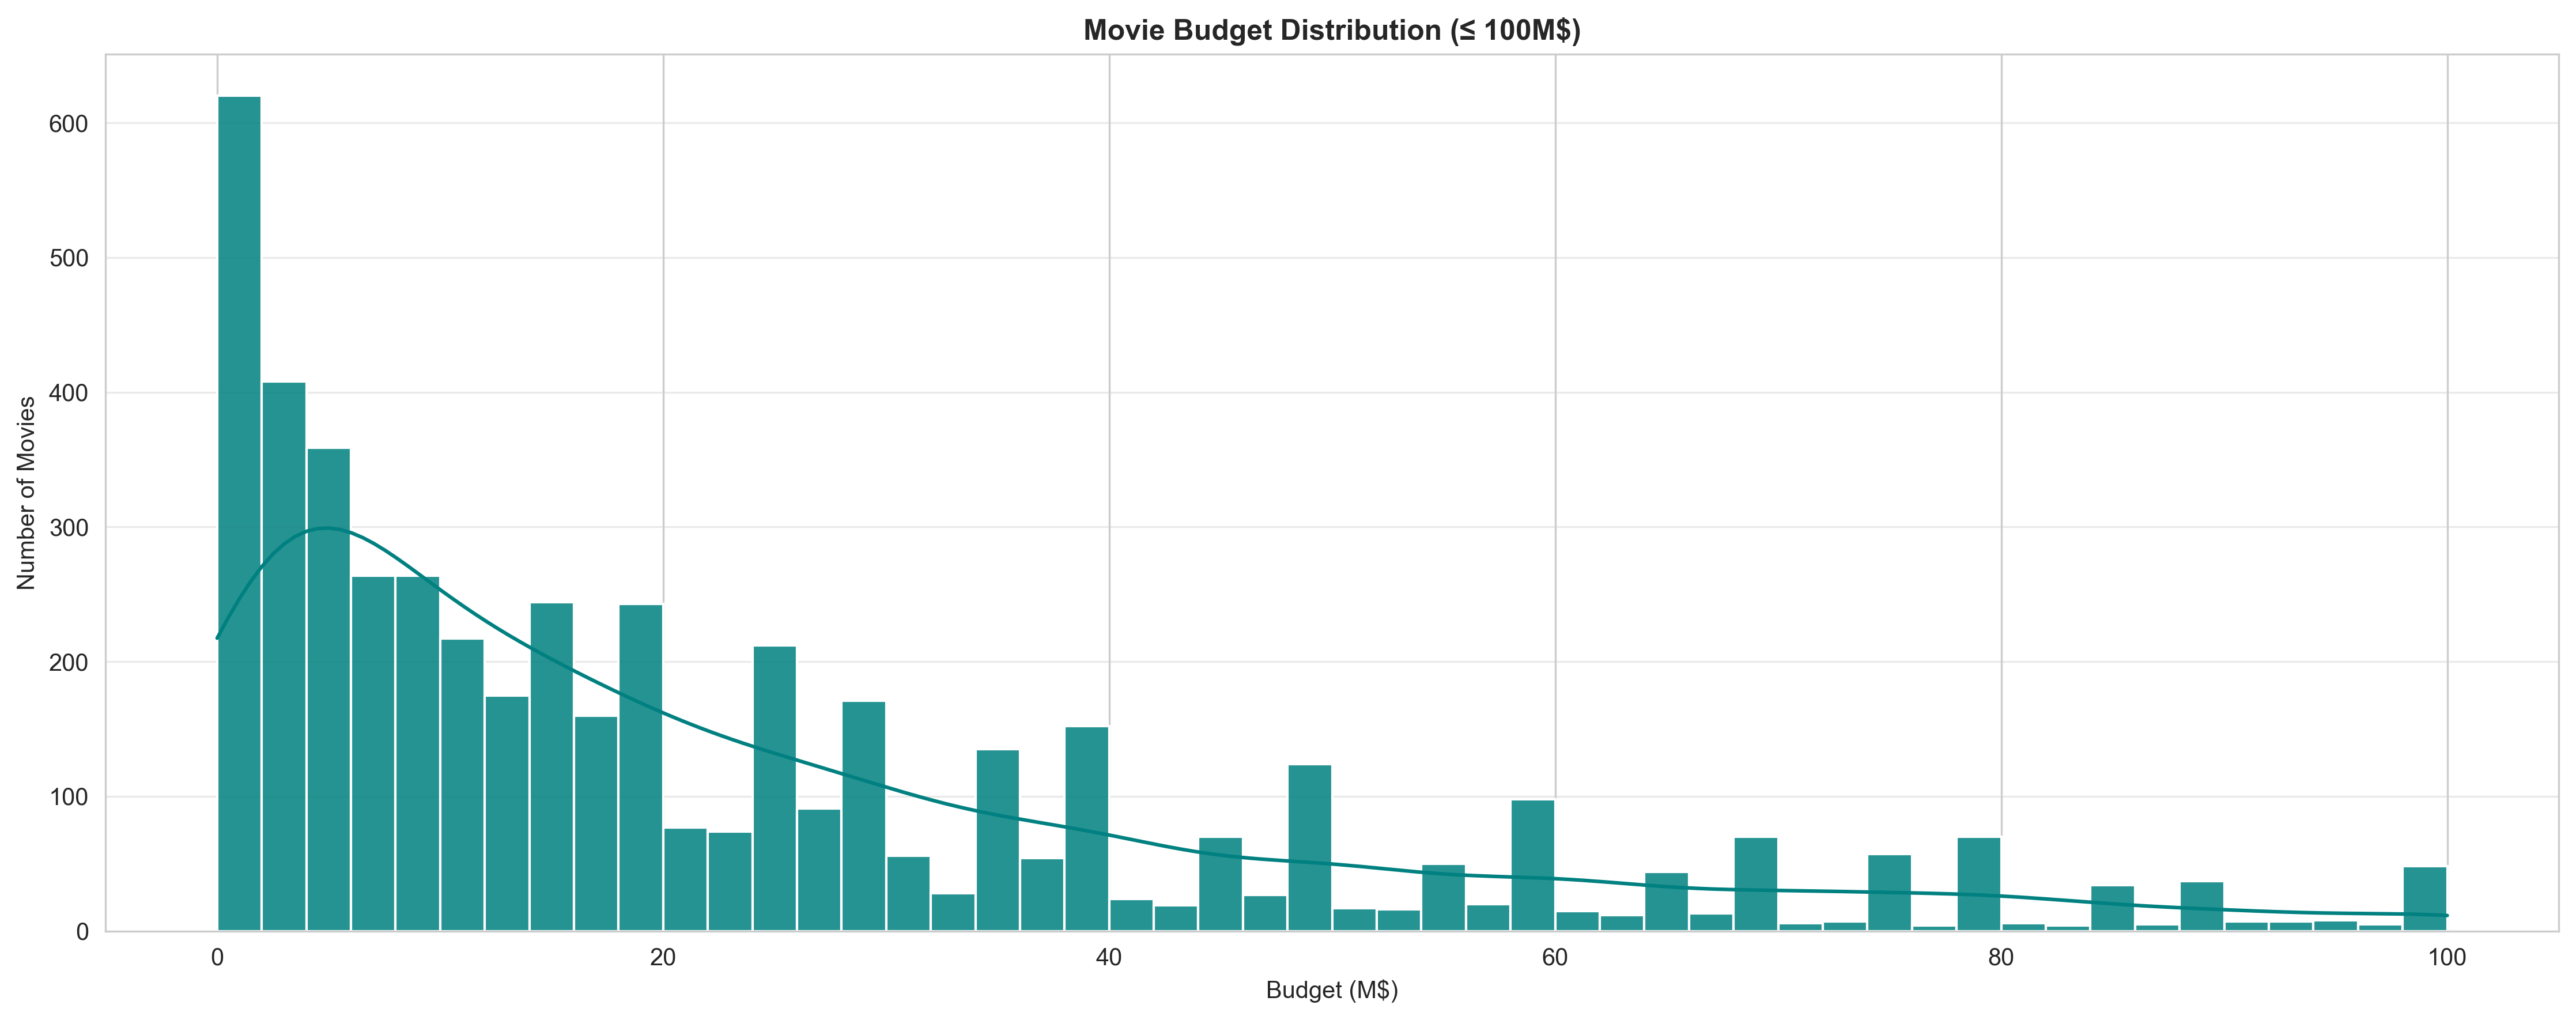

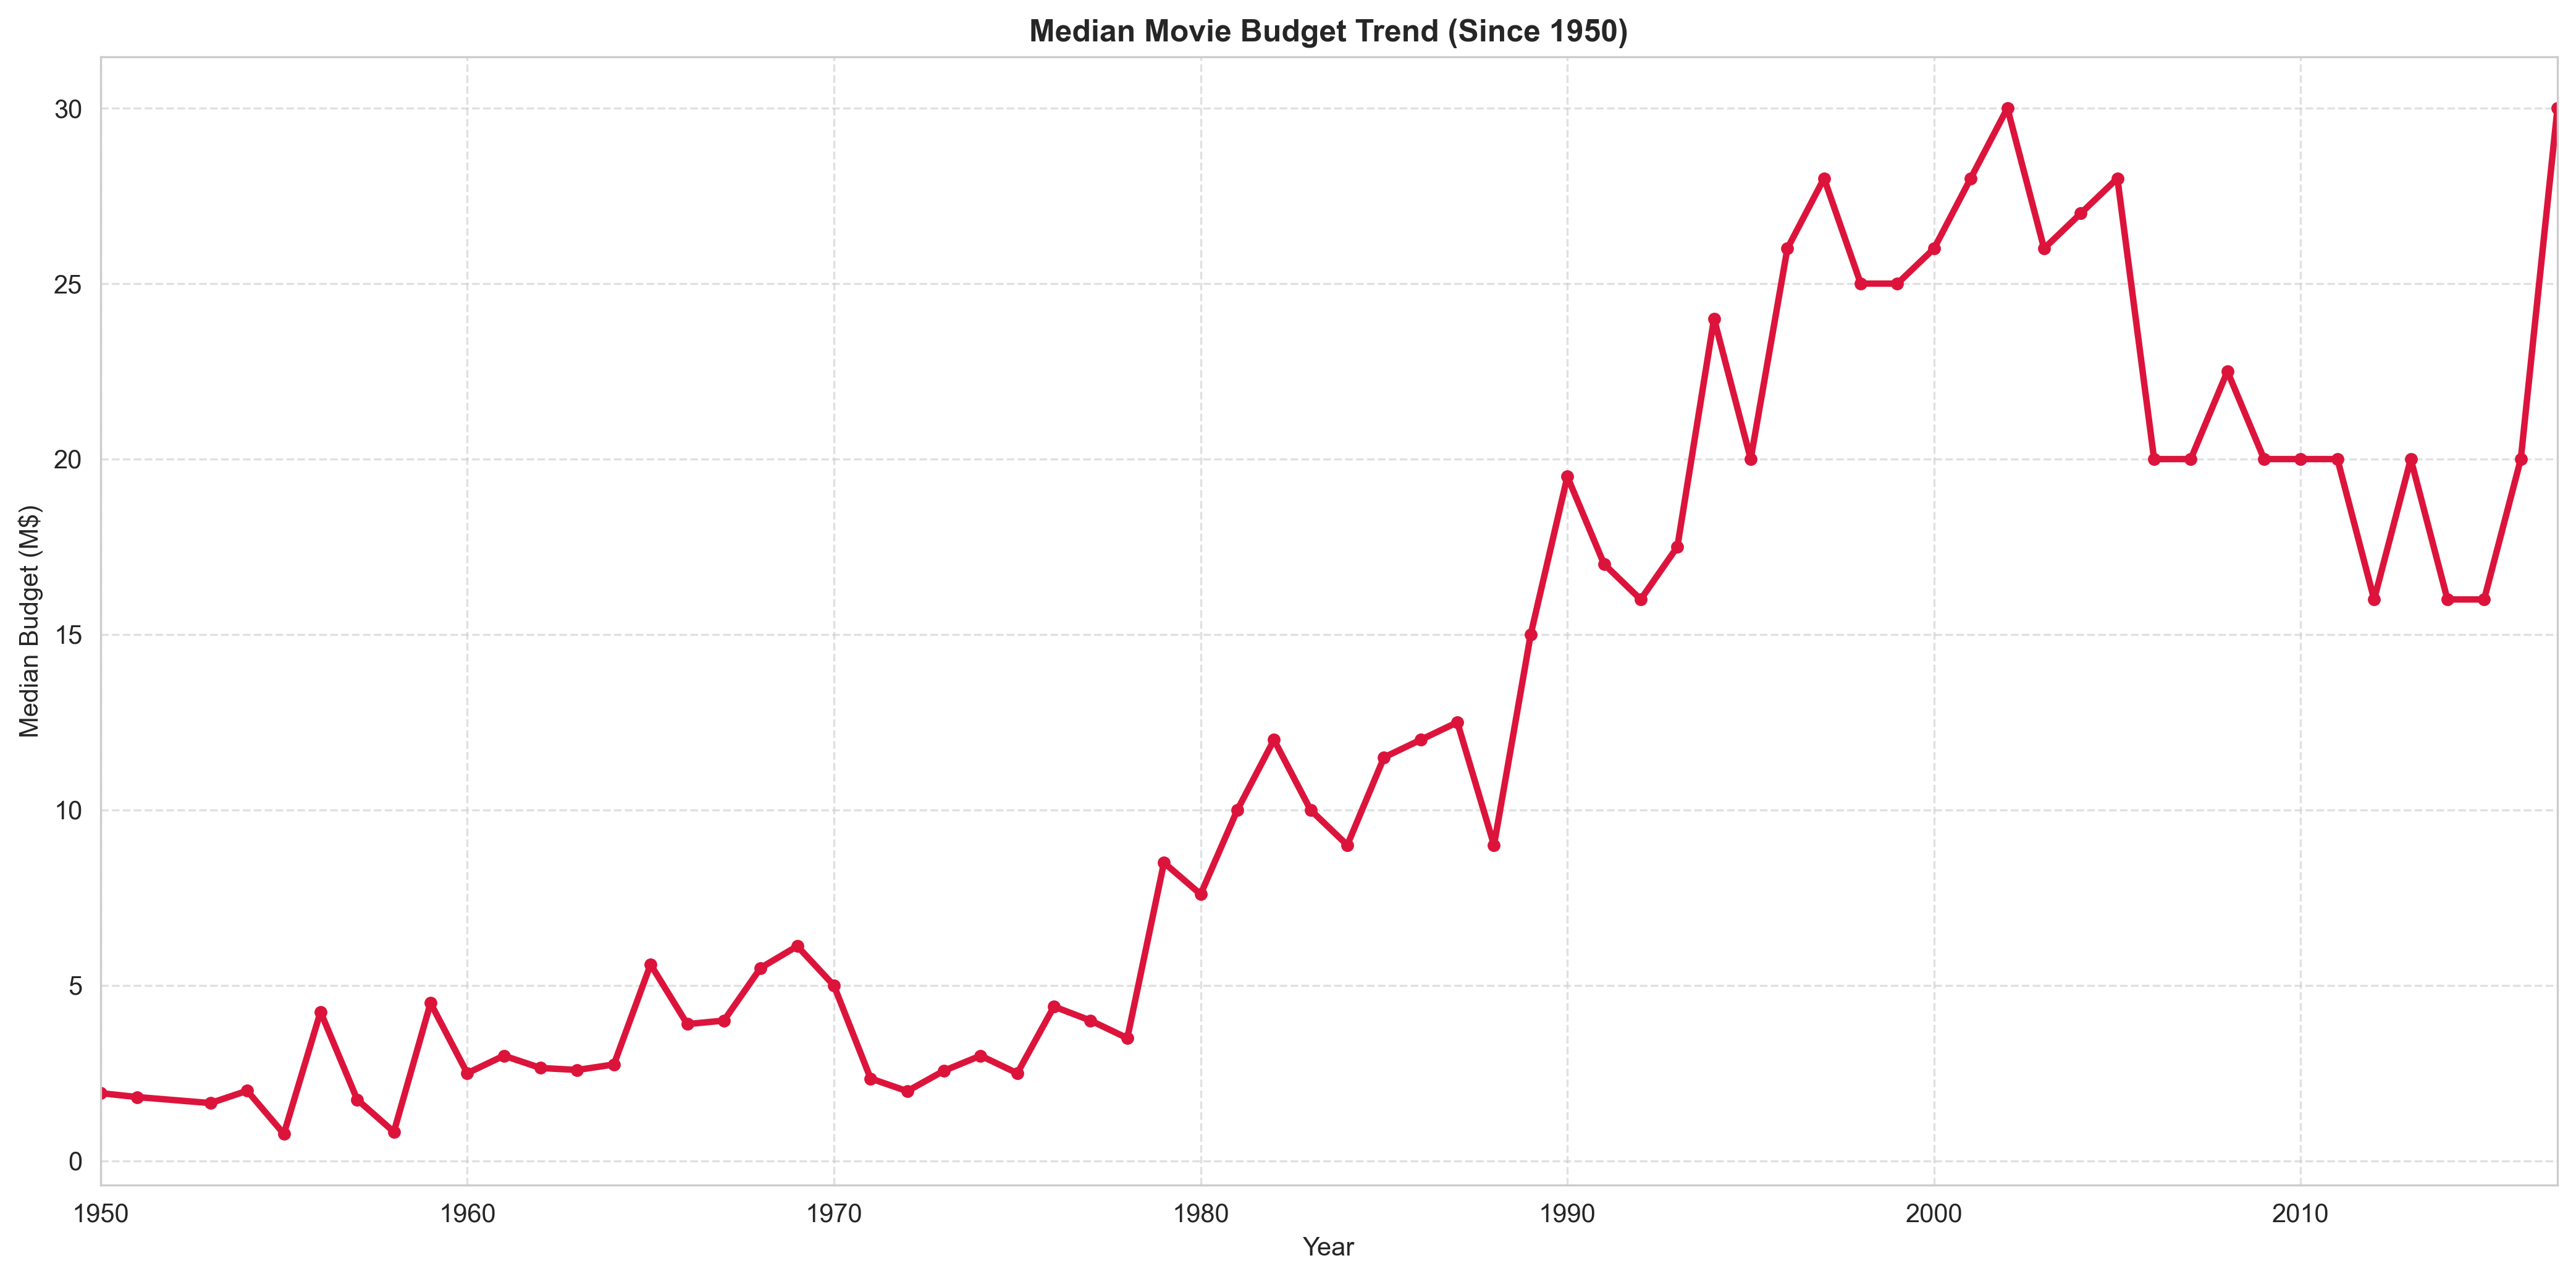

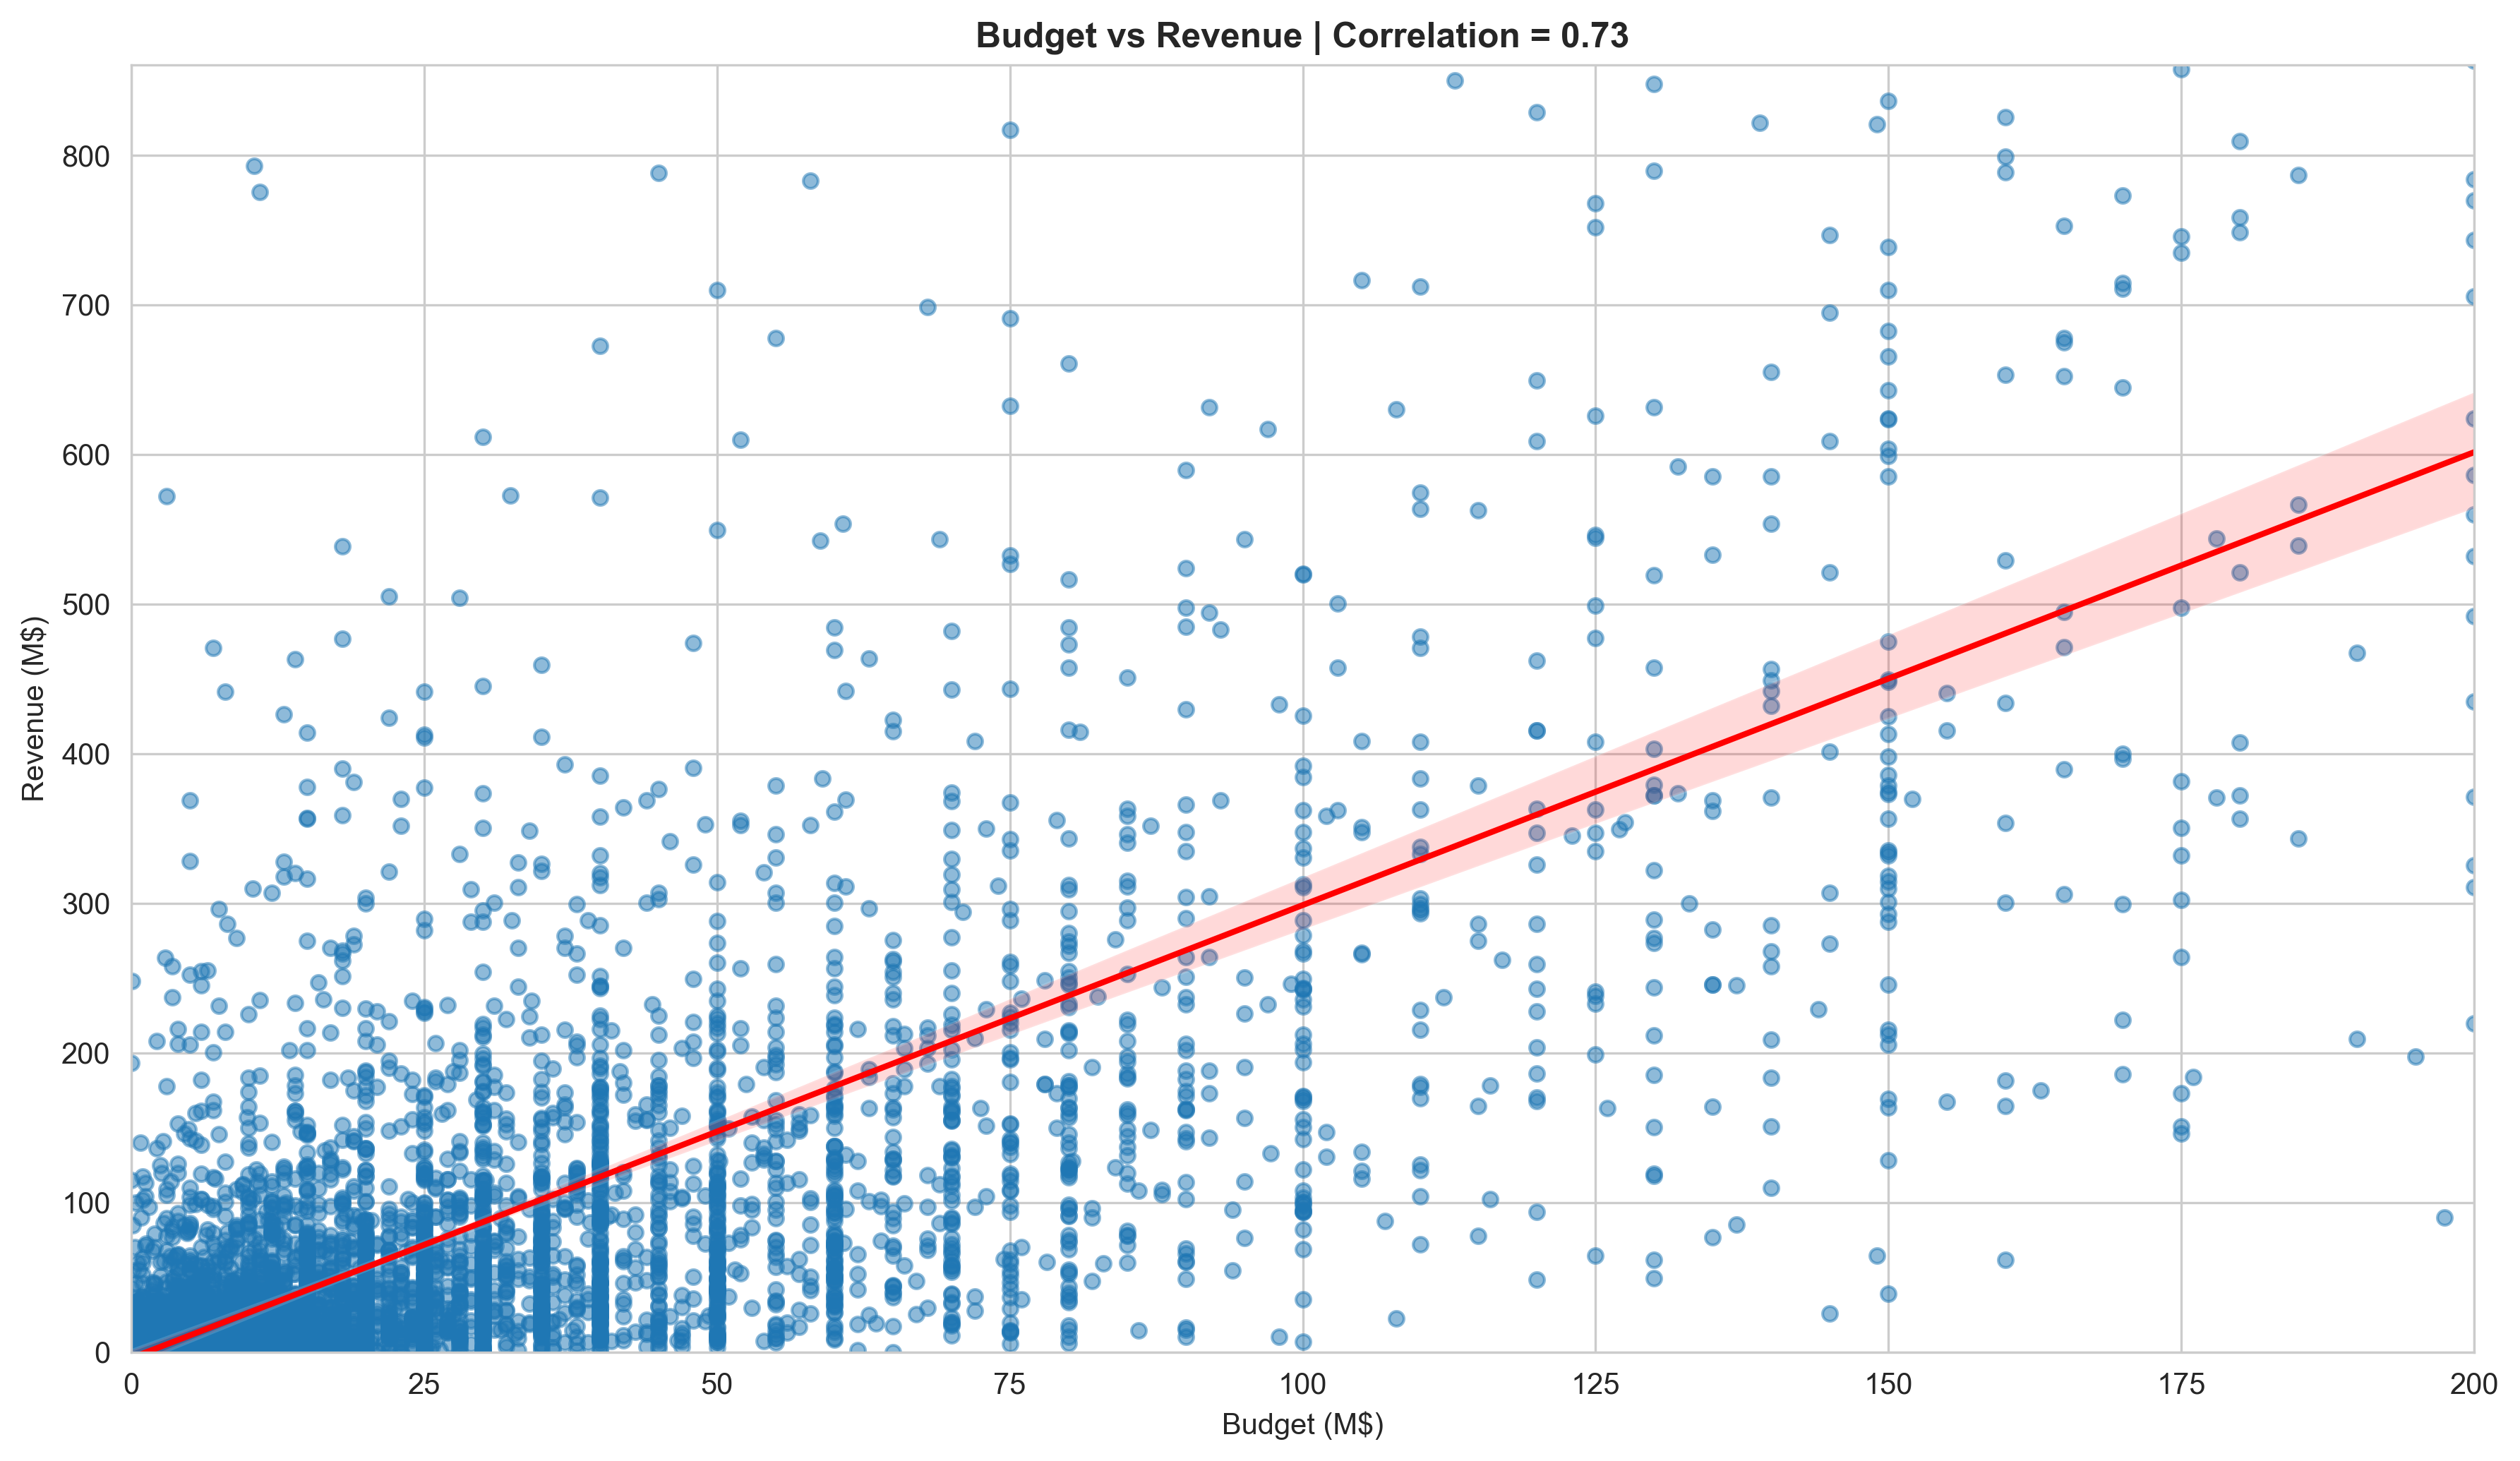

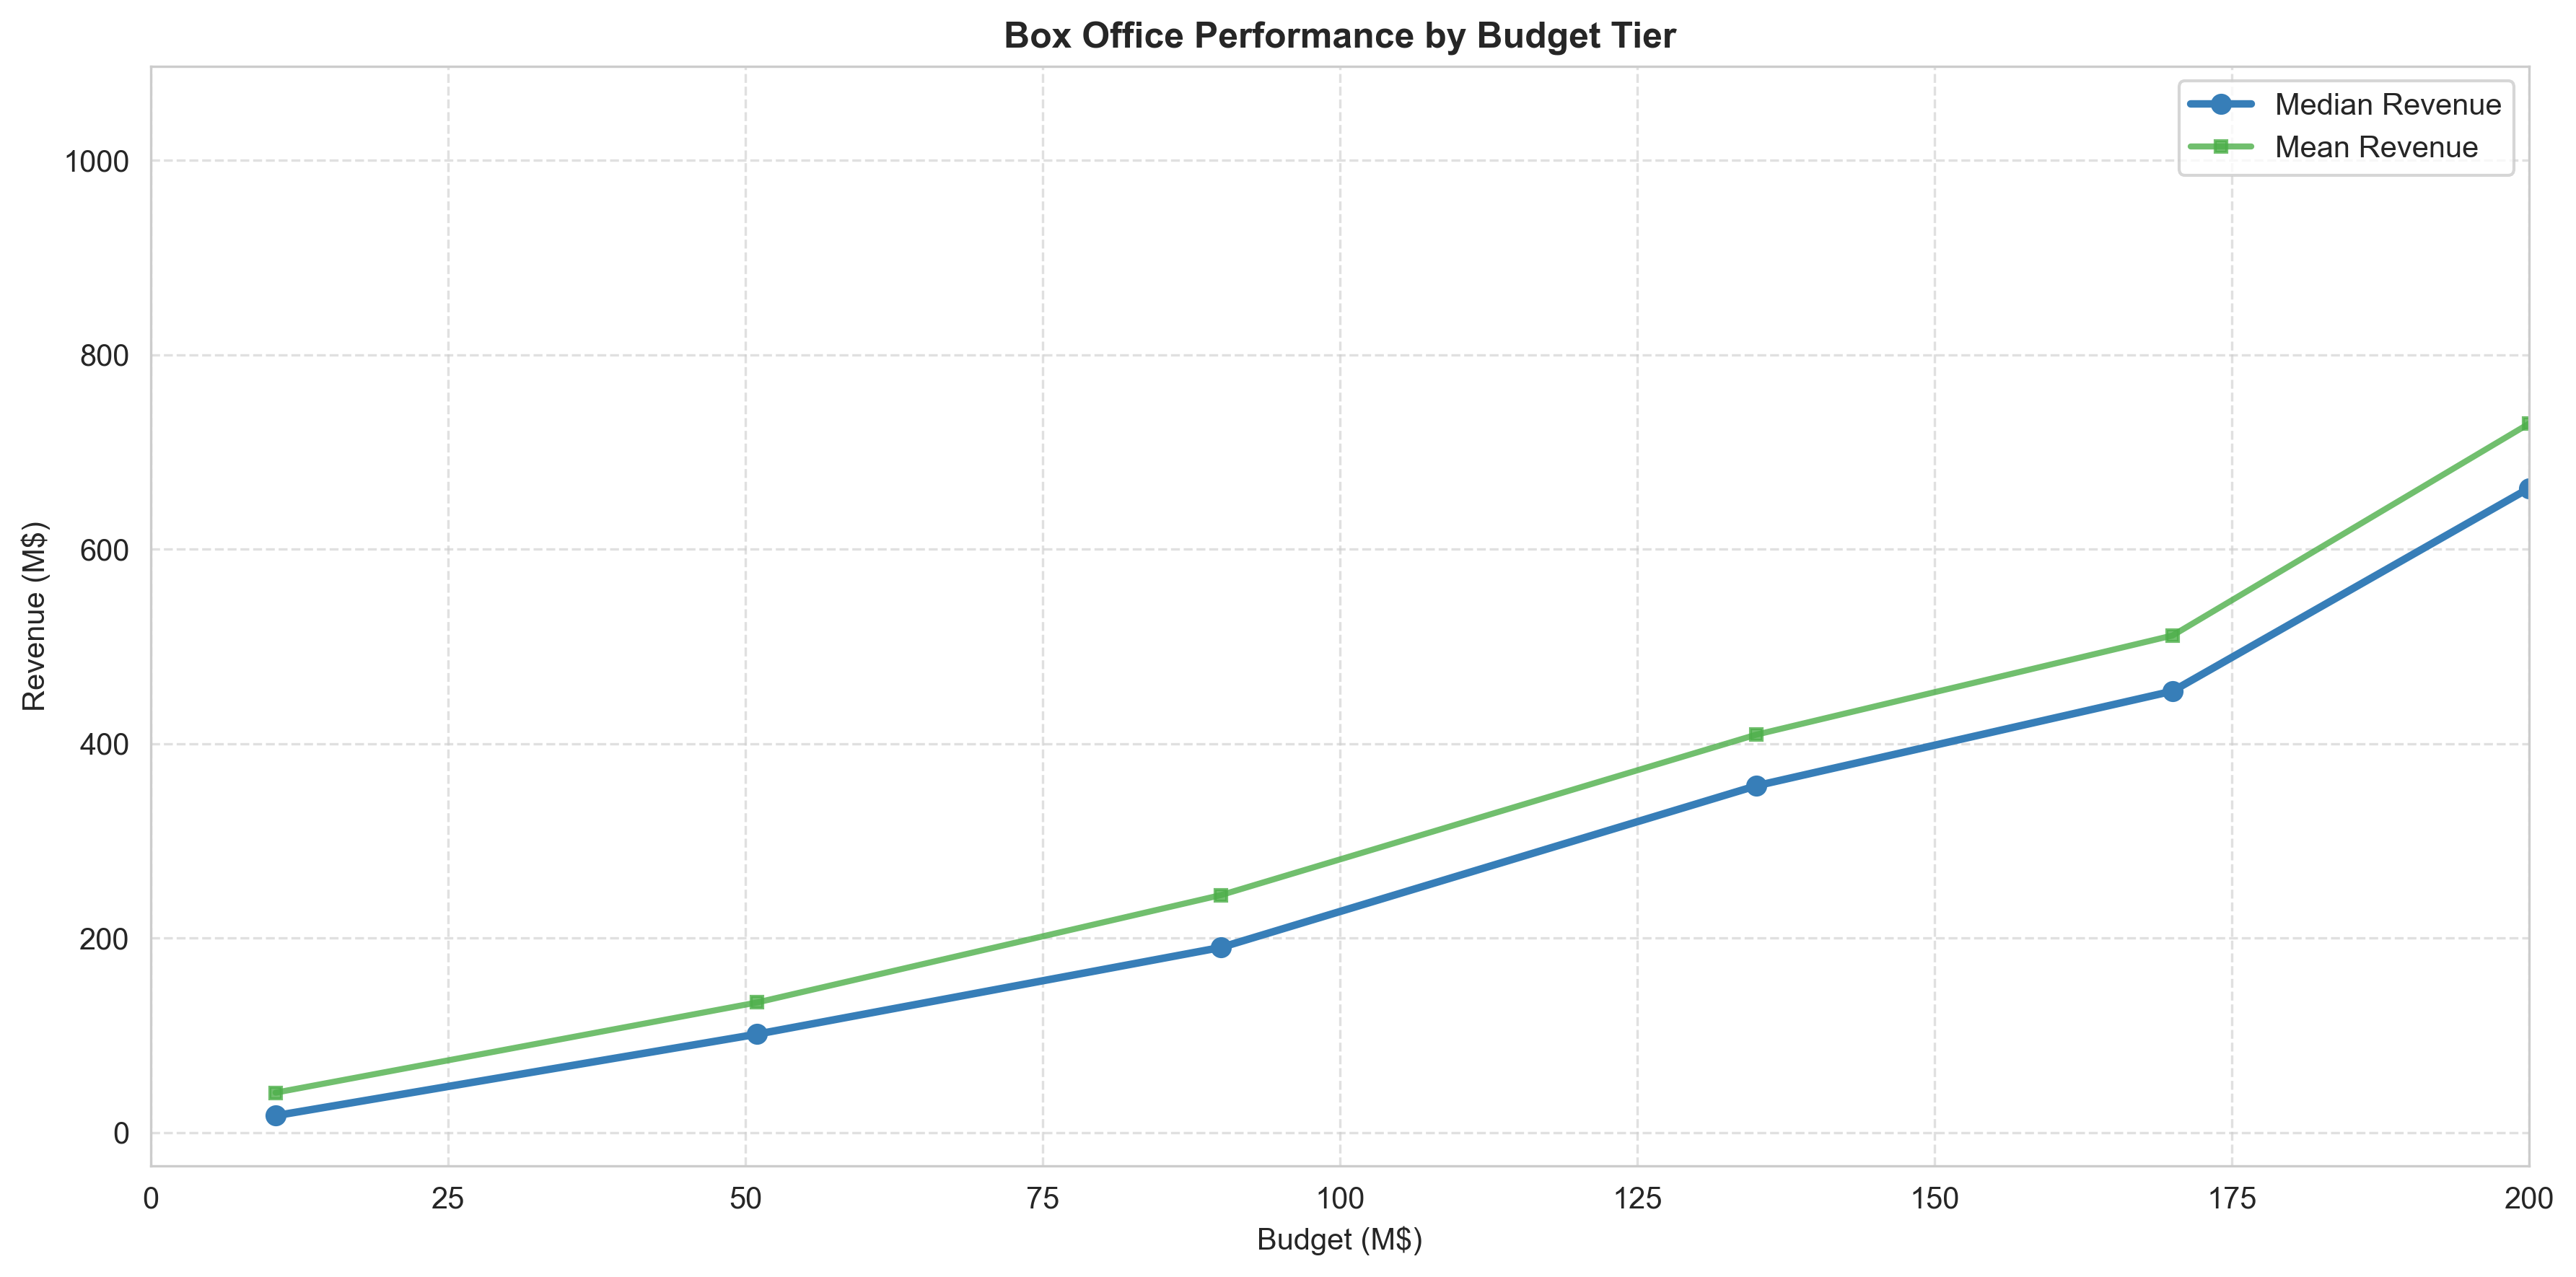

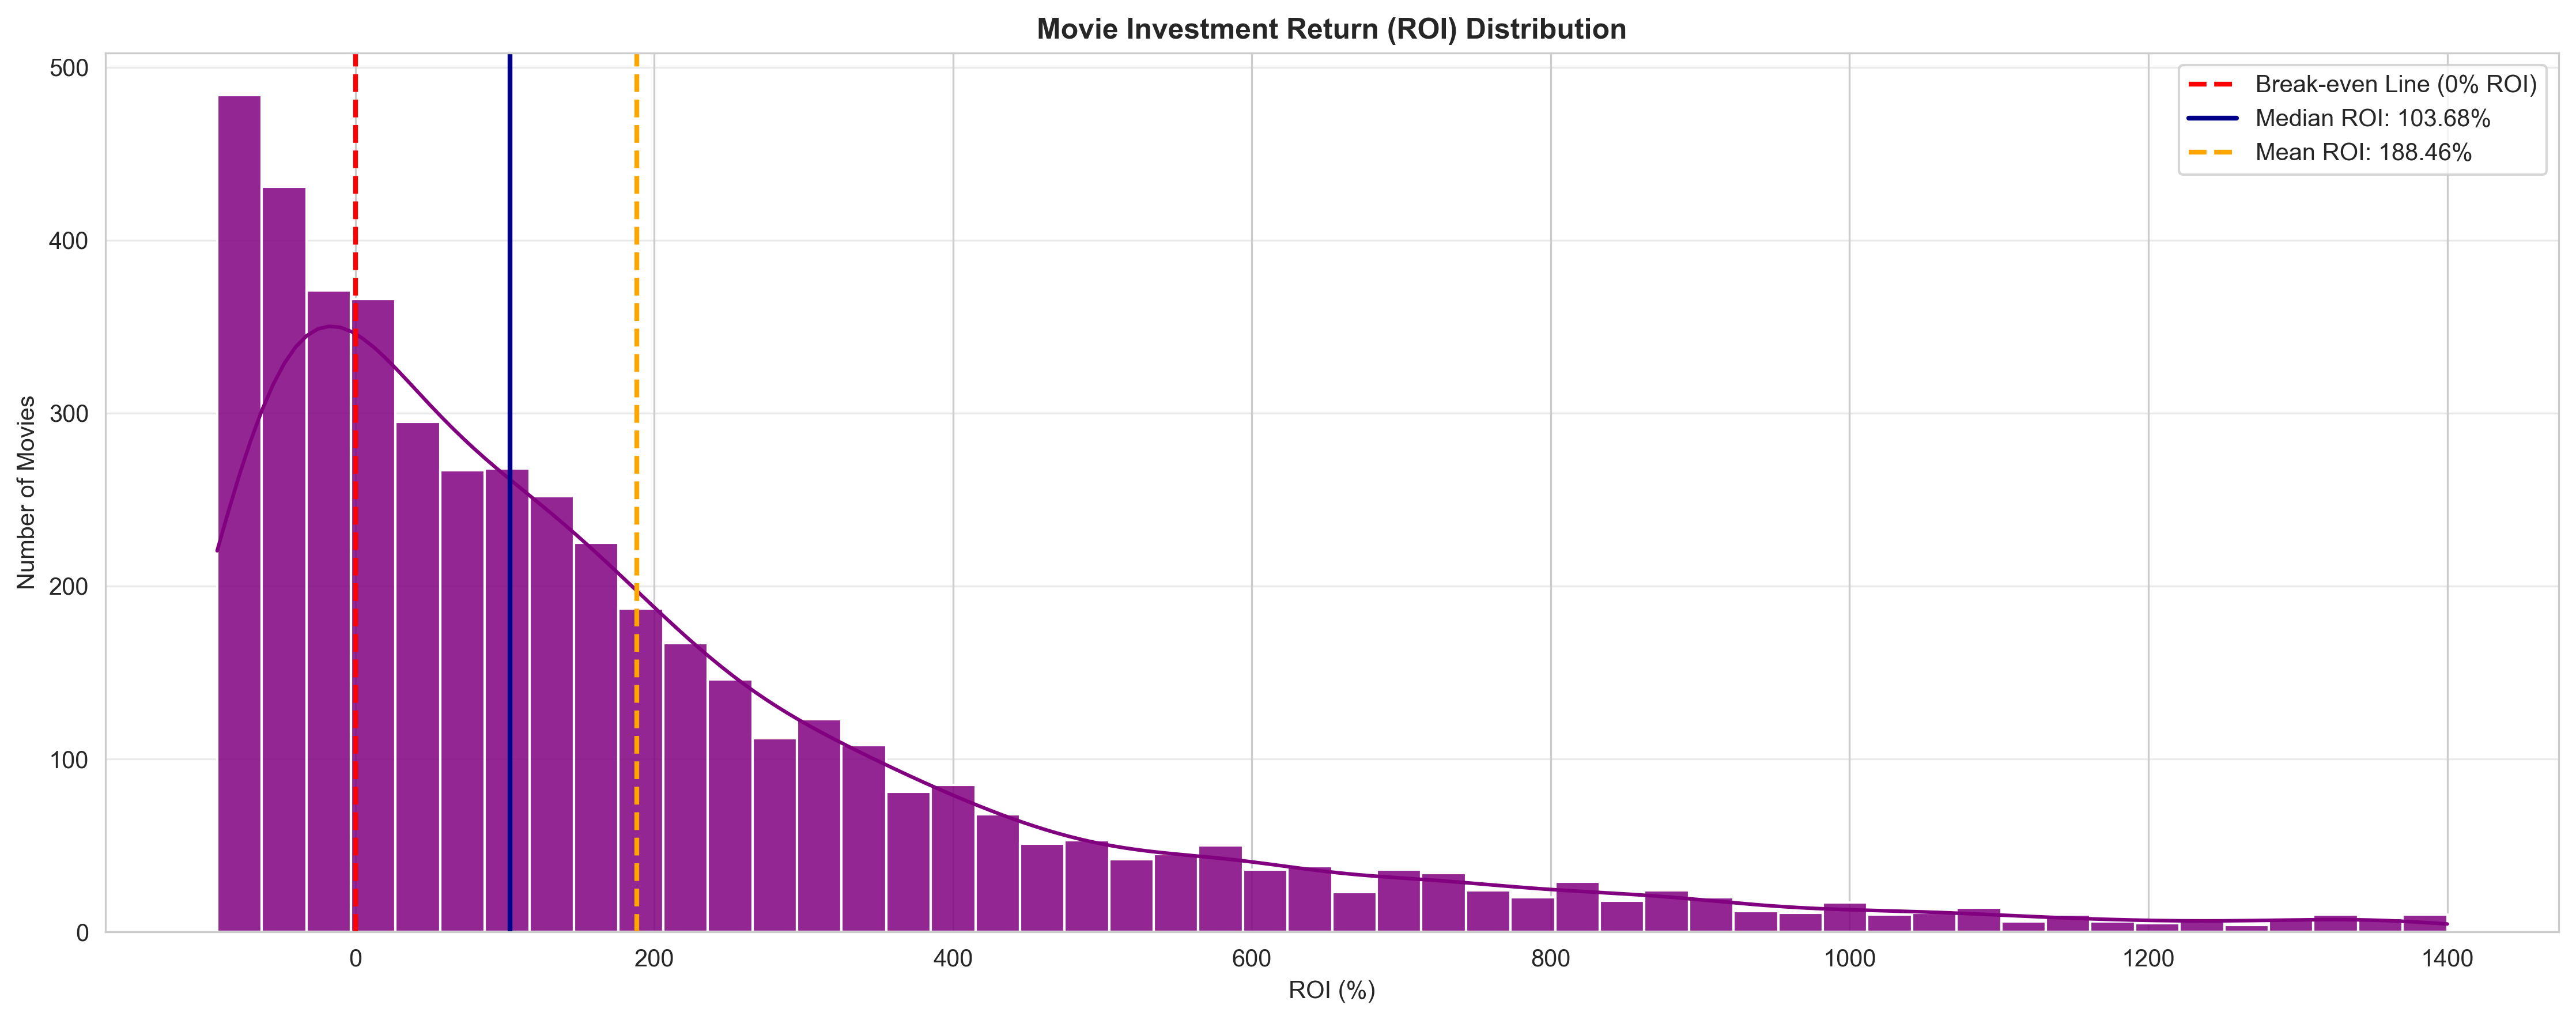


✅ Budget Tier ROI Ranking (by Median ROI):
   budget_M  Median_ROI_pct   Mean_ROI_pct  Sample_Count
0     250.0      273.583679     302.312619            19
1     280.0      220.333333     222.369370             3
2     200.0      211.966666     258.235247            35
3     170.0      177.641220     198.032492            64
4     380.0      175.187843     175.187843             1
5     135.0      165.233341     201.160747           159
6      90.0      119.004442     165.949284           279
7      10.5       96.438504  556623.153670          3852
8      51.0       87.796689     146.584518           841


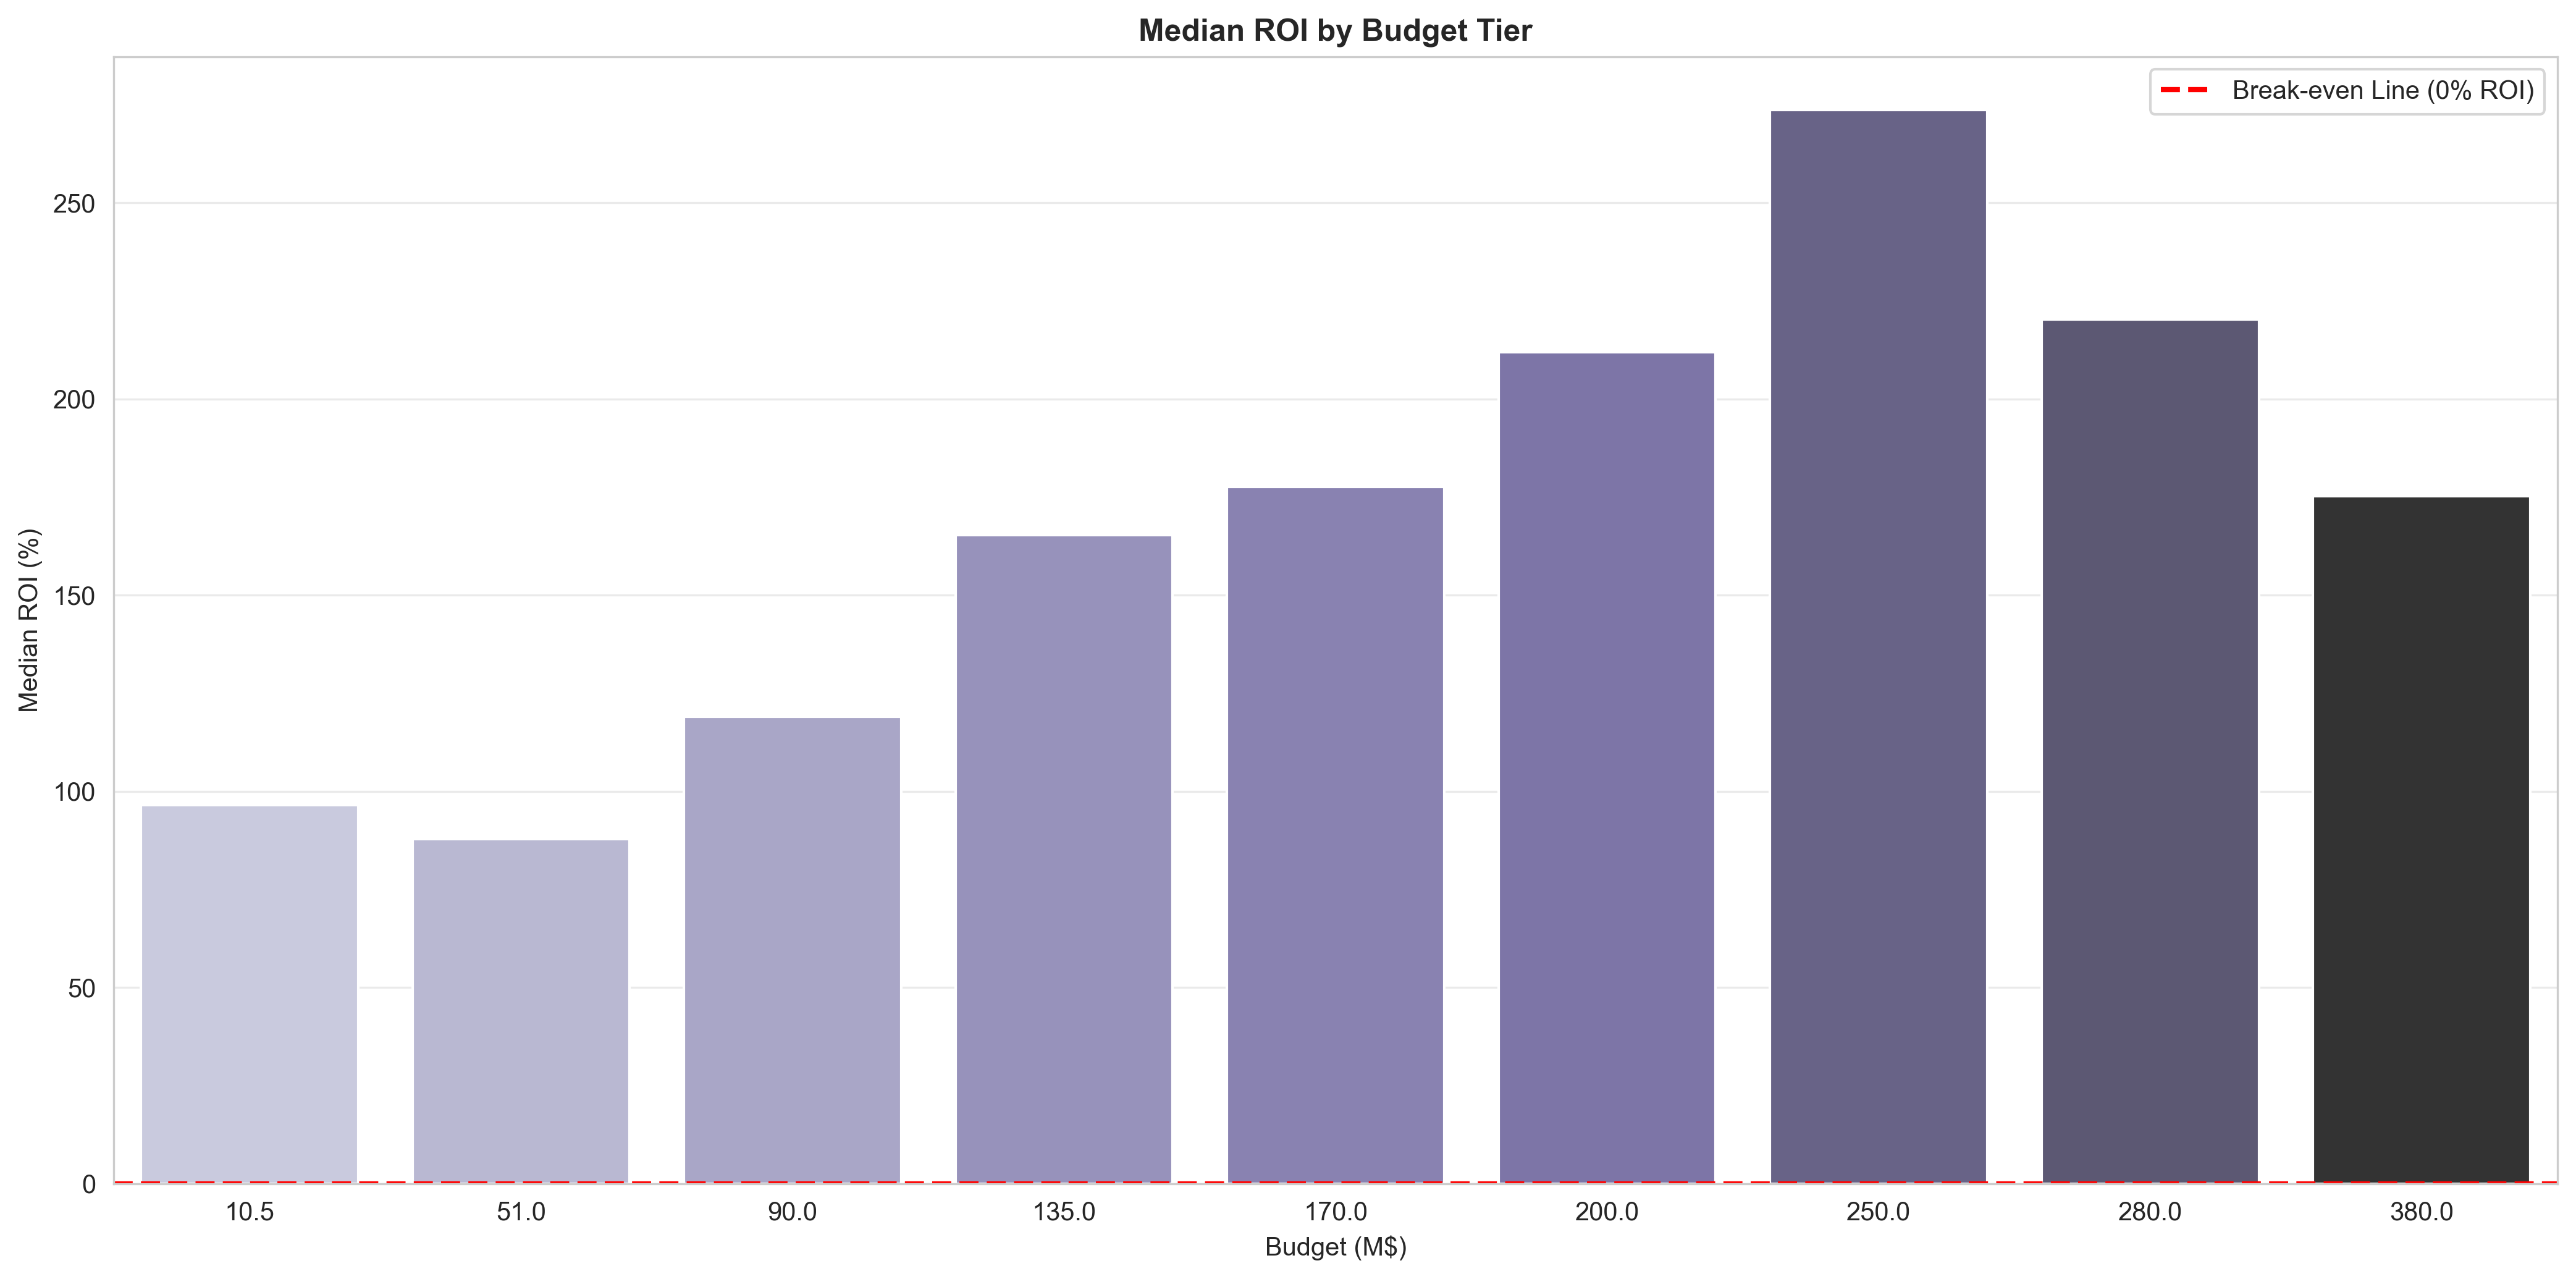

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

# --------------------------
# 2. 数据加载（替换为你的文件路径）
# --------------------------
# CSV文件在桌面，用这个路径
file_name = '../cleaned_archive/movies_metadata_box_office.csv'


# 读取数据（仅读取核心字段，运行更快）
df = pd.read_csv(file_name, usecols=['id', 'budget', 'revenue', 'release_date', 'release_year'])
print(f"✅ Data Loaded: {file_name} | Total Rows: {len(df)}")

# --------------------------
# 3. 数据清洗 & 预处理（新增ROI计算）
# --------------------------
# 替换0值为NaN（无效预算/票房数据）
df['budget'] = df['budget'].replace(0, np.nan)
df['revenue'] = df['revenue'].replace(0, np.nan)

# 日期格式转换 & 提取发行年份
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

# 筛选有效分析样本（剔除核心字段缺失值）
df_final = df.dropna(subset=['budget', 'release_year', 'revenue']).copy()
# 预算/票房转换为百万美元单位
df_final['budget_M'] = df_final['budget'] / 1_000_000
df_final['revenue_M'] = df_final['revenue'] / 1_000_000

# 【新增】计算投资回报率ROI（行业通用公式）
# ROI = (票房收入 - 制作预算) / 制作预算 * 100%
df_final['ROI_pct'] = ((df_final['revenue'] - df_final['budget']) / df_final['budget']) * 100
# 计算利润（百万美元）
df_final['profit_M'] = df_final['revenue_M'] - df_final['budget_M']

# 筛选1950年之后的电影（剔除早年样本量不足的年份）
df_analysis = df_final[df_final['release_year'] >= 1950].copy()
# 预算分箱（10个等宽区间，用于票房&ROI分析）
df_analysis['budget_bin'] = pd.cut(df_analysis['budget_M'], bins=10, labels=False)
# 计算每个预算区间的中位数预算（X轴坐标）
budget_mid = df_analysis.groupby('budget_bin')['budget_M'].median().reset_index()

print(f"✅ Valid Budget-Revenue-ROI Analysis Samples: {len(df_analysis)} movies")
print(f"✅ Overall Average ROI: {df_analysis['ROI_pct'].mean():.2f}%")
print(f"✅ Overall Median ROI: {df_analysis['ROI_pct'].median():.2f}%")

# --------------------------
# 4. 核心分析1：电影预算分布直方图
# --------------------------
max_budget_M = 100  # 限制1亿美元以内，剔除极端值影响
data_hist = df_analysis[df_analysis['budget_M'] <= max_budget_M]['budget_M']

plt.figure(figsize=(15, 6))
sns.histplot(data_hist, bins=50, color='teal', edgecolor='white', alpha=0.85, kde=True)
plt.title(f'Movie Budget Distribution (≤ {max_budget_M}M$)', fontweight='bold')
plt.xlabel('Budget (M$)')
plt.ylabel('Number of Movies')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

# --------------------------
# 5. 核心分析2：1950年以来电影年度预算趋势
# --------------------------
# 按年份分组计算中位数预算和样本量
budget_trend = df_analysis.groupby('release_year').agg(
    Median_Budget_M=('budget_M', 'median'),
    Sample_Count=('id', 'count')
).reset_index()
# 剔除每年样本量不足5部的年份
budget_trend = budget_trend[budget_trend['Sample_Count'] >= 5]

plt.figure(figsize=(14, 7))
plt.plot(budget_trend['release_year'], budget_trend['Median_Budget_M'],
         marker='o', linewidth=2.5, color='crimson', markersize=4)
plt.title('Median Movie Budget Trend (Since 1950)', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Median Budget (M$)')
plt.xticks(np.arange(1950, budget_trend['release_year'].max() + 1, 10))
plt.xlim(1950, budget_trend['release_year'].max())
plt.grid(linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --------------------------
# 6. 核心分析3：预算 vs 全球票房 相关性分析
# --------------------------
plt.figure(figsize=(12,7))
# 带95%置信区间的回归散点图
sns.regplot(
    x='budget_M', y='revenue_M', data=df_analysis,
    scatter_kws={'alpha':0.5, 's':25},
    line_kws={'color':'red', 'linewidth':2},
    ci=95
)
# 计算皮尔逊相关系数
corr = df_analysis['budget_M'].corr(df_analysis['revenue_M'])
plt.title(f'Budget vs Revenue | Correlation = {corr:.2f}', fontweight='bold')
plt.xlabel('Budget (M$)')
plt.ylabel('Revenue (M$)')
# 限制坐标轴范围，剔除极端值
plt.xlim(0, df_analysis['budget_M'].quantile(0.99))
plt.ylim(0, df_analysis['revenue_M'].quantile(0.99))
plt.tight_layout()
plt.show()

# --------------------------
# 7. 核心分析4：不同预算区间的票房表现
# --------------------------
# 按预算区间计算票房统计
budget_revenue_trend = df_analysis.groupby('budget_bin').agg(
    Median_Revenue_M=('revenue_M', 'median'),
    Mean_Revenue_M=('revenue_M', 'mean'),
    Sample_Count=('id', 'count')
).reset_index()
budget_revenue_trend = pd.merge(budget_revenue_trend, budget_mid, on='budget_bin')

plt.figure(figsize=(12, 6))
plt.plot(budget_revenue_trend['budget_M'], budget_revenue_trend['Median_Revenue_M'],
         marker='o', linewidth=2.5, color='#377eb8', markersize=6, label='Median Revenue')
plt.plot(budget_revenue_trend['budget_M'], budget_revenue_trend['Mean_Revenue_M'],
         marker='s', linewidth=2, color='#4daf4a', markersize=4, alpha=0.8, label='Mean Revenue')
plt.title('Box Office Performance by Budget Tier', fontweight='bold')
plt.xlabel('Budget (M$)')
plt.ylabel('Revenue (M$)')
plt.grid(linestyle='--', alpha=0.6)
plt.xlim(0, df_analysis['budget_M'].quantile(0.99))
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------
# 【新增1】核心分析5：电影投资回报率（ROI）分布分析
# --------------------------
# 限制ROI范围，剔除极端值（避免少数爆款电影影响图表可读性）
max_roi_pct = df_analysis['ROI_pct'].quantile(0.95)
min_roi_pct = df_analysis['ROI_pct'].quantile(0.05)
roi_data = df_analysis[(df_analysis['ROI_pct'] >= min_roi_pct) & (df_analysis['ROI_pct'] <= max_roi_pct)]['ROI_pct']

plt.figure(figsize=(15, 6))
sns.histplot(roi_data, bins=50, color='purple', edgecolor='white', alpha=0.85, kde=True)
# 添加盈亏线
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Break-even Line (0% ROI)')
# 添加中位数/均值线
median_roi = roi_data.median()
mean_roi = roi_data.mean()
plt.axvline(x=median_roi, color='darkblue', linestyle='-', linewidth=2, label=f'Median ROI: {median_roi:.2f}%')
plt.axvline(x=mean_roi, color='orange', linestyle='--', linewidth=2, label=f'Mean ROI: {mean_roi:.2f}%')

plt.title(f'Movie Investment Return (ROI) Distribution', fontweight='bold')
plt.xlabel('ROI (%)')
plt.ylabel('Number of Movies')
plt.grid(axis='y', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------
# 【新增3】核心分析6：不同预算区间ROI排名&对比
# --------------------------
# 按预算区间计算ROI统计
budget_roi_trend = df_analysis.groupby('budget_bin').agg(
    Median_ROI_pct=('ROI_pct', 'median'),
    Mean_ROI_pct=('ROI_pct', 'mean'),
    Sample_Count=('id', 'count')
).reset_index()
budget_roi_trend = pd.merge(budget_roi_trend, budget_mid, on='budget_bin')
# 按中位数ROI降序排名
budget_roi_ranking = budget_roi_trend.sort_values('Median_ROI_pct', ascending=False).reset_index(drop=True)

print("\n✅ Budget Tier ROI Ranking (by Median ROI):")
print(budget_roi_ranking[['budget_M', 'Median_ROI_pct', 'Mean_ROI_pct', 'Sample_Count']])

# 绘图：不同预算区间中位数ROI对比
plt.figure(figsize=(14, 7))
sns.barplot(
    x='budget_M', 
    y='Median_ROI_pct', 
    hue='budget_M', 
    data=budget_roi_trend, 
    palette='Purples_d', 
    legend=False
)
# 添加盈亏线
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Break-even Line (0% ROI)')
plt.title('Median ROI by Budget Tier', fontweight='bold')
plt.xlabel('Budget (M$)')
plt.ylabel('Median ROI (%)')
plt.grid(axis='y', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()
